In [1]:
# ============================================
# Importing Essential Data Science Libraries
# ============================================

# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression

# Gradient Boosting Libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Explainable AI
import shap

# Hyperparameter Optimization
import optuna

# Web App Deployment
import streamlit as st

# Jupyter Notebook Display Settings
from IPython.display import display

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# ============================================
# Basic Setup
# ============================================

# Pandas Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Seaborn Theme
sns.set(style='whitegrid')

print("All libraries imported successfully!")

ModuleNotFoundError: No module named 'lightgbm'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_csv("OnlineRetail.csv", encoding='latin1')

In [8]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df = df.dropna(subset=['CustomerID'])

In [11]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [12]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['CustomerID'] = df['CustomerID'].astype(int)

In [14]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [16]:
import os

# Create data folder if it does not exist
os.makedirs("../data", exist_ok=True)

# Save cleaned dataframe
df.to_csv("../data/cleaned_retail.csv", index=False)

print("File saved successfully!")

File saved successfully!


# PHASE 4 — Exploratory Data Analysis (EDA)

# Monthly Revenue

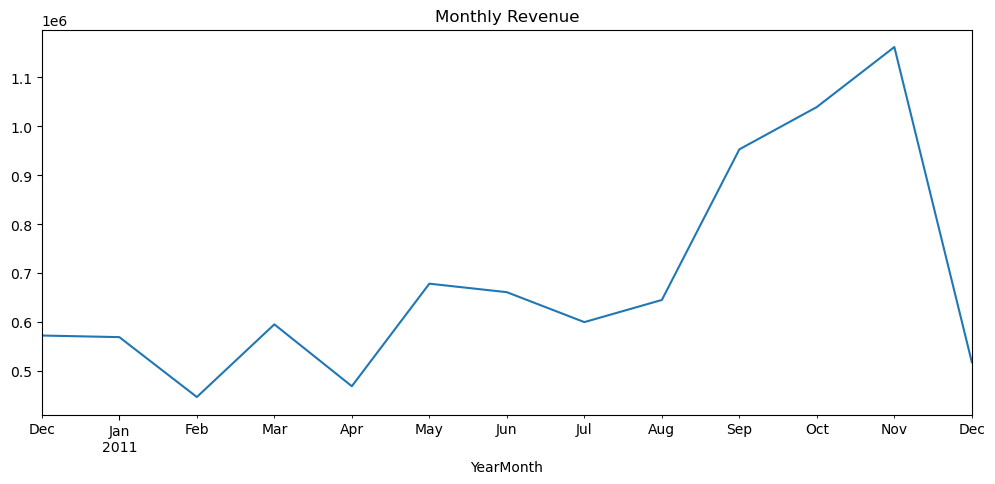

In [17]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('YearMonth')['Revenue'].sum()

monthly_revenue.plot(figsize=(12,5))
plt.title("Monthly Revenue")
plt.show()

# Customer-Level Aggregation(This is where feature engineering begins.)

In [18]:
customer_df = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Revenue': ['sum', 'mean'],
    'Quantity': ['sum', 'mean'],
    'InvoiceDate': ['min', 'max']
})

# Feature Engineering (MOST IMPORTANT)

In [19]:
03_feature_engineering.ipynb

SyntaxError: invalid decimal literal (2405561310.py, line 1)

# Create Snapshot Date

In [20]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)  ##Needed for recency calculations.

# Build RFM Features

In [21]:
recency = df.groupby('CustomerID')['InvoiceDate'].max()

recency = (snapshot_date - recency).dt.days

In [22]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [23]:
monetary = df.groupby('CustomerID')['Revenue'].sum()

# Create Advanced Features

In [25]:
basket_size = df.groupby('CustomerID')['Quantity'].mean()  ##Average Basket Size

In [26]:
customer_days = df.groupby('CustomerID')['InvoiceDate'].agg(['min', 'max'])

customer_days['days_active'] = (
    customer_days['max'] - customer_days['min']
).dt.days + 1         ##Purchase Velocity

In [27]:
purchase_velocity = frequency / customer_days['days_active']

In [28]:
product_diversity = df.groupby('CustomerID')['StockCode'].nunique()   ##Product Diversity

In [29]:
avg_transaction_value = monetary / frequency   ##Average Revenue Per Transaction

In [30]:
purchase_std = df.groupby('CustomerID')['Revenue'].std()    ##Purchase Consistency

In [31]:
features = pd.concat([
    recency,
    frequency,
    monetary,
    basket_size,
    purchase_velocity,
    product_diversity,
    avg_transaction_value,
    purchase_std
], axis=1)        ##Combine Features

# PHASE 6 — Churn Label Creation

In [34]:
import pandas as pd

# Convert invoice date to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Calculate latest date
snapshot_date = df['InvoiceDate'].max()

# Create recency feature
features = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days
}).reset_index()

# Rename column
features.rename(columns={'InvoiceDate': 'recency'}, inplace=True)

# Create churn column
features['churn'] = np.where(features['recency'] > 90, 1, 0)

features.head()

,CustomerID,recency,churn
0,12346,325,1
1,12347,1,0
2,12348,74,0
3,12349,18,0
4,12350,309,1


# PHASE 7 — Modeling

In [ ]:
04_modeling.ipynb

# Step 21: Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split

X = features.drop('churn', axis=1)
y = features['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 22: Train Models

Start with:

Logistic Regression
Random Forest
XGBoost

In [36]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Step 23: Evaluate

Use: ROC-AUC, Precision, Recall, F1 Score

# Step 24: SHAP Explainability

This step makes your project look VERY strong.

In [42]:
# Install SHAP library
!pip install shap


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [43]:
import sys
!{sys.executable} -m pip install shap


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [45]:
# Fix NumPy + SHAP compatibility issue

# Step 1: Upgrade pip
!pip install --upgrade pip

# Step 2: Reinstall compatible versions
!pip uninstall -y numpy shap
!pip install numpy==1.26.4
!pip install shap==0.45.0

# Step 3: Restart Kernel after installation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.6 MB/s  0:00:004.1 MB/s eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
Found existing installation: shap 0.51.0
Uninstalling shap-0.51.0:
  Successfully uninstalled shap-0.51.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 43.1 MB/s  0:00:00.0 MB/s eta 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
  Attempting uninstall: slicer
    Found existing installation: slicer 0.0.8
    Uninstalling slicer-0

In [46]:
import numpy as np
import shap

# Create SHAP explainer
explainer = shap.Explainer(model)

# Generate SHAP values
shap_values = explainer(X_test)

# Summary Plot
shap.summary_plot(shap_values, X_test)

ImportError: cannot import name '_sub_module_deprecation' from 'scipy._lib.deprecation' (/Users/monika/anaconda3/lib/python3.11/site-packages/scipy/_lib/deprecation.py)

# PHASE 8 — CLV Prediction

After churn is done.

Target:

future revenue

Use:

XGBoost Regressor
LightGBM